In [1]:
import json
import os
import sys
from datetime import datetime
from pathlib import Path
from typing import Literal

from pydantic import BaseModel, Field

In [2]:
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

In [3]:
from src.gepa.scaffold import GepaConfig, run_optimization_pipeline
from src.gepa.data_utils import create_dataset_from_dicts
from src.gepa.lm import get_openai_model
from src.gepa.types import DataInstWithInput, RolloutOutput

In [4]:
class PassengerInput(BaseModel):
    """Input features for Titanic survival prediction."""
    
    passenger_class: Literal[1, 2, 3] = Field(
        description="Passenger class (1=First, 2=Second, 3=Third)"
    )
    sex: Literal["male", "female"] = Field(
        description="Passenger's sex"
    )
    age: float = Field(
        description="Passenger's age in years"
    )
    siblings_spouses: int = Field(
        description="Number of siblings/spouses aboard"
    )
    parents_children: int = Field(
        description="Number of parents/children aboard"
    )
    fare: float = Field(
        description="Passenger fare paid in pounds"
    )
    embarked: Literal["C", "Q", "S", "Unknown"] = Field(
        description="Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton)"
    )


class SurvivalPrediction(BaseModel):
    """Output prediction for Titanic survival."""
    
    survived: Literal["yes", "no"] = Field(
        description="Whether the passenger survived"
    )
    confidence: float = Field(
        description="Confidence score between 0 and 1",
        ge=0.0,
        le=1.0
    )
    reasoning: str = Field(
        description="Detailed explanation of the prediction based on the features"
    )

In [5]:
import pandas as pd


def load_titanic_data(n_train: int = 50, n_holdout: int = 15) -> tuple[list[dict], list[dict]]:
    """Load and prepare Titanic dataset for GEPA with holdout test set.
    
    Args:
        n_train: Number of samples to use for training/validation (default 50)
        n_holdout: Number of samples to hold out for final testing (default 15)
        
    Returns:
        Tuple of (training_data, holdout_data) as lists of dictionaries
    """
    # Load Titanic dataset from seaborn
    try:
        import seaborn as sns
        df = sns.load_dataset('titanic')
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Make sure seaborn is installed: pip install seaborn")
        raise
    
    # Select interesting features and clean data
    df = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']].copy()
    
    # Drop rows with missing critical values
    df = df.dropna(subset=['age', 'fare'])
    
    # Fill missing embarked with 'Unknown'
    df['embarked'] = df['embarked'].fillna('Unknown')
    
    # Convert survived to string labels
    df['survived_label'] = df['survived'].map({0: 'no', 1: 'yes'})
    
    # Sample diverse examples - stratified by survival and class
    # First, separate into train and holdout sets
    train_dfs = []
    holdout_dfs = []
    
    for survived in [0, 1]:
        for pclass in [1, 2, 3]:
            subset = df[(df['survived'] == survived) & (df['pclass'] == pclass)]
            if len(subset) > 0:
                # Calculate proportional samples for this stratum
                n_train_stratum = min(len(subset), max(1, n_train // 6))
                n_holdout_stratum = min(len(subset) - n_train_stratum, max(1, n_holdout // 6))
                
                # Shuffle and split
                subset_shuffled = subset.sample(frac=1.0, random_state=42)
                train_dfs.append(subset_shuffled.iloc[:n_train_stratum])
                
                if n_holdout_stratum > 0 and len(subset_shuffled) > n_train_stratum:
                    holdout_dfs.append(subset_shuffled.iloc[n_train_stratum:n_train_stratum + n_holdout_stratum])
    
    # Combine and limit to requested sizes
    df_train = pd.concat(train_dfs, ignore_index=True)
    if len(df_train) > n_train:
        df_train = df_train.sample(n=n_train, random_state=42)
    
    df_holdout = pd.concat(holdout_dfs, ignore_index=True) if holdout_dfs else pd.DataFrame()
    if len(df_holdout) > n_holdout:
        df_holdout = df_holdout.sample(n=n_holdout, random_state=43)
    
    # Convert to list of dicts
    def df_to_dict_list(df: pd.DataFrame) -> list[dict]:
        """Convert DataFrame to list of dictionaries."""
        data = []
        for _, row in df.iterrows():
            data.append({
                'passenger_class': int(row['pclass']),
                'sex': str(row['sex']),
                'age': float(row['age']),
                'siblings_spouses': int(row['sibsp']),
                'parents_children': int(row['parch']),
                'fare': float(row['fare']),
                'embarked': str(row['embarked']),
                'label': str(row['survived_label'])
            })
        return data
    
    train_data = df_to_dict_list(df_train)
    holdout_data = df_to_dict_list(df_holdout)
    
    return train_data, holdout_data

In [6]:
def survival_metric(
    data_inst: DataInstWithInput[PassengerInput],
    output: RolloutOutput[SurvivalPrediction],
) -> tuple[float, str | None]:
    """Evaluate survival prediction accuracy.
    
    This metric checks if the predicted survival matches the ground truth.
    It also considers confidence calibration as a bonus.
    
    Args:
        data_inst: Input data instance with metadata containing ground truth.
        output: Agent's output to evaluate.
        
    Returns:
        Tuple of (score, feedback) where score is between 0.0 and 1.0.
    """
    # Check if the agent execution was successful
    if not output.success or output.result is None:
        return 0.0, output.error_message or "Agent failed to produce output"
    
    # Extract predicted survival
    predicted_survival = output.result.survived
    confidence = output.result.confidence
    
    # Extract ground truth from metadata
    ground_truth = data_inst.metadata.get("label")
    
    if ground_truth is None:
        return 0.0, "No ground truth label found in metadata"
    
    # Base score: correct prediction gets 1.0, incorrect gets 0.0
    if predicted_survival == ground_truth:
        # Bonus for high confidence on correct predictions
        score = 0.7 + (0.3 * confidence)
        feedback = f"✓ Correct: {predicted_survival} (confidence: {confidence:.2f})"
    else:
        # Penalty scales with confidence on wrong predictions
        score = 0.3 * (1 - confidence)
        feedback = f"✗ Incorrect: predicted {predicted_survival}, expected {ground_truth} (confidence: {confidence:.2f})"
    
    return score, feedback

In [7]:
train_data, holdout_data = load_titanic_data(n_train=20, n_holdout=25)

print(f"Loaded {len(train_data)} training records")
print(f"Loaded {len(holdout_data)} holdout test records")

Loaded 18 training records
Loaded 24 holdout test records


In [8]:
train_survival_counts = {}
for record in train_data:
    label = record['label']
    train_survival_counts[label] = train_survival_counts.get(label, 0) + 1

holdout_survival_counts = {}
for record in holdout_data:
    label = record['label']
    holdout_survival_counts[label] = holdout_survival_counts.get(label, 0) + 1

print(f"Training survival distribution: {train_survival_counts}")
print(f"Holdout survival distribution: {holdout_survival_counts}")

Training survival distribution: {'no': 9, 'yes': 9}
Holdout survival distribution: {'no': 12, 'yes': 12}


In [9]:
from src.gepa.data_utils import prepare_train_val_sets


trainset, valset = prepare_train_val_sets(
    train_data,
    input_model=PassengerInput,
    input_keys=['passenger_class', 'sex', 'age', 'siblings_spouses', 
                'parents_children', 'fare', 'embarked'],
    metadata_keys=['label'],
    train_ratio=0.75,
    shuffle=True,
    random_seed=42,
)

print(f"Created training dataset with {len(trainset)} examples and {len(valset)} validation examples")

Created training dataset with 13 examples and 5 validation examples


In [10]:
reflection_model = "gpt-4.1"
agent_model="gpt-4.1-mini"


config = GepaConfig(
    # Agent configuration
    agent_model=agent_model,
    agent_instructions=(
        "Predict Titanic survival based on the passenger's features."
    ),
    input_type=PassengerInput,
    output_type=SurvivalPrediction,
    
    # Data and evaluation
    trainset=trainset,
    valset=valset,
    metric=survival_metric,
    # auto="light",
    # max_metric_calls=500,
    max_full_evals=5,
    
    # Optimization parameters
    module_selector="all",
    candidate_selection_strategy="pareto",
    optimize_tools=True,
    use_merge=True,
    
    # LLM for reflection
    reflection_model=reflection_model,
    
    # Display options
    display_progress_bar=True,
    track_best_outputs=True,
    
    # Caching for faster iterations
    enable_cache=True,
    cache_dir=".gepa_cache",
    
    # Output settings
    output_dir="optimization_results",
    save_result=True,
)

In [11]:
import nest_asyncio

nest_asyncio.apply()


result = run_optimization_pipeline(config)

Dataset: 13 training, 5 validation examples
Starting GEPA optimization...
Running GEPA for approx 90 metric calls of the program. This amounts to 5.00 full evals on the train+val set.


GEPA Optimization:   0%|          | 0/90 [00:00<?, ?rollouts/s]

Iteration 0: Base program full valset score: 0.579 over 5 / 5 examples
Iteration 1: Selected program 0 score: 0.579
Iteration 1: Proposed new text for instructions: Predict whether a Titanic passenger survived based on their individual features using common patterns from historical survival data. Consider key survival likelihood indicators: 
- Female passengers had higher survival rates
- First and second class passengers had higher survival rates than third class
- Younger passengers and those accompanied by children/parents or higher fares may have increased survival likelihood
- Southampton (S), Cherbourg (C), and Queenstown (Q) refer to ports of embarkation
Provide clear reasoning referencing these patterns, and output a confidence score.
Iteration 1: Proposed new text for tool:final_result:description: Return a Titanic survival prediction based on input features. Include predicted survival ('yes' or 'no'), a confidence score (0–1), and concise, factual justification referencing hi

GEPA Optimization:  18%|█▊        | 16/90 [00:26<02:01,  1.64s/rollouts]

Iteration 1: Valset score for new program: 0.579 (coverage 5 / 5)
Iteration 1: Val aggregate for new program: 0.579
Iteration 1: Individual valset scores for new program: {0: 0.955, 1: 0.9249999999999999, 2: 0.9249999999999999, 3: 0.045000000000000005, 4: 0.045000000000000005}
Iteration 1: New valset pareto front scores: {0: 0.955, 1: 0.9249999999999999, 2: 0.9249999999999999, 3: 0.045000000000000005, 4: 0.045000000000000005}
Iteration 1: Valset pareto front aggregate score: 0.579
Iteration 1: Updated valset pareto front programs: {0: {0, 1}, 1: {0, 1}, 2: {0, 1}, 3: {0, 1}, 4: {0, 1}}
Iteration 1: Best valset aggregate score so far: 0.579
Iteration 1: Best program as per aggregate score on valset: 0
Iteration 1: Best score on valset: 0.579
Iteration 1: Linear pareto front program index: 0
Iteration 1: New program candidate index: 1
Iteration 2: No merge candidates found
Iteration 2: Selected program 1 score: 0.579
Iteration 2: Proposed new text for instructions: Predict whether a Tita

...

Iteration 8: New subsample score 1.9549999999999998 is not better than old score 2.8049999999999997, skipping
Iteration 9: Selected program 3 score: 0.585
Iteration 9: Proposed new text for instructions: Predict Titanic survival for an individual passenger using all provided features, following detailed historically accurate survival patterns observed in Titanic records. For each input, analyze every feature's effect on survival rates, prioritizing them as follows: sex (female = strongest advantage), class (1st > 2nd > 3rd), age (children under 15 = strong advantage), family aboard (beneficial especially to minors/females), fare (as supporting evidence for class), and port of embarkation (as weak supportive context). Output must include detailed, data-driven step-by-step reasoning for each feature, a clear survival prediction ('yes' or 'no'), and an appropriately calibrated confidence score (0–1). Justify your confidence by explaining the dominance or interplay of features per the actu

GEPA Optimization:  88%|████████▊ | 79/90 [08:45<01:55, 10.54s/rollouts]

Iteration 9: New subsample score 2.8649999999999998 is not better than old score 2.9099999999999997, skipping
Iteration 10: Selected program 3 score: 0.585
Iteration 10: Proposed new text for instructions: Predict Titanic survival based on all listed passenger features, applying detailed historical data patterns:

Critical historical facts:
- Men in first class, traveling alone and not children, did not have high survival rates despite their status—being male and adult sharply lowered survival odds even in first class. High fare alone does not override male/adult risk.
- First and second class adult males not accompanied by family, and not children (<15), were less likely to survive, even with a high fare. Only a minority did survive.
- Female sex or child (<15) is the dominant survival indicator, irrespective of class but especially powerful in first/second class. Nearly all first/second class females survived, and most children did, regardless of class.
- Immediate family presence (s

GEPA Optimization:  88%|████████▊ | 79/90 [10:08<01:24,  7.70s/rollouts]

Iteration 10: Found a better program on the valset with score 0.7759999999999999.
Iteration 10: Valset score for new program: 0.7759999999999999 (coverage 5 / 5)
Iteration 10: Val aggregate for new program: 0.7759999999999999
Iteration 10: Individual valset scores for new program: {0: 0.97, 1: 0.955, 2: 0.97, 3: 0.955, 4: 0.029999999999999992}
Iteration 10: New valset pareto front scores: {0: 0.97, 1: 0.955, 2: 0.97, 3: 0.955, 4: 0.045000000000000005}
Iteration 10: Valset pareto front aggregate score: 0.7789999999999999
Iteration 10: Updated valset pareto front programs: {0: {3, 5}, 1: {5}, 2: {2, 4, 5}, 3: {5}, 4: {0, 1, 3}}
Iteration 10: Best valset aggregate score so far: 0.7759999999999999
Iteration 10: Best program as per aggregate score on valset: 5
Iteration 10: Best score on valset: 0.7759999999999999
Iteration 10: Linear pareto front program index: 5
Iteration 10: New program candidate index: 5

✅ Optimization result saved to: optimization_results\optimization_20251116_173159.

In [18]:
original_candidate = {
    "instructions": "Predict Titanic survival based on the passenger's features.",
    "tool:final_result:description": "Output prediction for Titanic survival.",
    "tool:final_result:param:survived": "Whether the passenger survived",
    "tool:final_result:param:confidence": "Confidence score between 0 and 1",
    "tool:final_result:param:reasoning": "Detailed explanation of the prediction based on the features",
    "signature:PassengerInput:instructions": "Input features for Titanic survival prediction.",
    "signature:PassengerInput:passenger_class:desc": "Passenger class (1=First, 2=Second, 3=Third)",
    "signature:PassengerInput:sex:desc": "Passenger's sex",
    "signature:PassengerInput:age:desc": "Passenger's age in years",
    "signature:PassengerInput:siblings_spouses:desc": "Number of siblings/spouses aboard",
    "signature:PassengerInput:parents_children:desc": "Number of parents/children aboard",
    "signature:PassengerInput:fare:desc": "Passenger fare paid in pounds",
    "signature:PassengerInput:embarked:desc": "Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton)"
  }

original_candidate

{'instructions': "Predict Titanic survival based on the passenger's features.",
 'tool:final_result:description': 'Output prediction for Titanic survival.',
 'tool:final_result:param:survived': 'Whether the passenger survived',
 'tool:final_result:param:confidence': 'Confidence score between 0 and 1',
 'tool:final_result:param:reasoning': 'Detailed explanation of the prediction based on the features',
 'signature:PassengerInput:instructions': 'Input features for Titanic survival prediction.',
 'signature:PassengerInput:passenger_class:desc': 'Passenger class (1=First, 2=Second, 3=Third)',
 'signature:PassengerInput:sex:desc': "Passenger's sex",
 'signature:PassengerInput:age:desc': "Passenger's age in years",
 'signature:PassengerInput:siblings_spouses:desc': 'Number of siblings/spouses aboard',
 'signature:PassengerInput:parents_children:desc': 'Number of parents/children aboard',
 'signature:PassengerInput:fare:desc': 'Passenger fare paid in pounds',
 'signature:PassengerInput:embark

In [14]:
from IPython.display import Markdown, display

# Create markdown content for the results
markdown_content = f"""
## Optimization Results

**Best Score:** {result.best_score:.4f}
"""

if result.original_score is not None:
    markdown_content += f"**Original Score:** {result.original_score:.4f}\n"
    improvement = result.improvement_ratio()
    if improvement is not None:
        markdown_content += f"**Improvement:** {improvement:+.2%}\n"

markdown_content += f"""
**Iterations:** {result.num_iterations}
**Metric Calls:** {result.num_metric_calls}
**GEPA Input Tokens:** {result.gepa_usage.input_tokens}
**GEPA Output Tokens:** {result.gepa_usage.output_tokens}

## Optimized Components

"""

for component_name, component_value in result.best_candidate.items():
    markdown_content += f"### {component_name}\n\n{component_value}\n\n"

display(Markdown(markdown_content))


## Optimization Results

**Best Score:** 0.7760
**Original Score:** 0.5790
**Improvement:** +34.02%

**Iterations:** 6
**Metric Calls:** 90
**GEPA Input Tokens:** 696095
**GEPA Output Tokens:** 21720

## Optimized Components

### instructions

Predict Titanic survival based on all listed passenger features, applying detailed historical data patterns:

Critical historical facts:
- Men in first class, traveling alone and not children, did not have high survival rates despite their status—being male and adult sharply lowered survival odds even in first class. High fare alone does not override male/adult risk.
- First and second class adult males not accompanied by family, and not children (<15), were less likely to survive, even with a high fare. Only a minority did survive.
- Female sex or child (<15) is the dominant survival indicator, irrespective of class but especially powerful in first/second class. Nearly all first/second class females survived, and most children did, regardless of class.
- Immediate family presence (siblings/spouses, parents/children) provides a moderate survival boost, more so for children/minors. For solo adult males (even in first), absence of family is a risk, but secondary to sex/age-class interaction.
- Port of embarkation is only relevant to support class/sex predictions, not as a primary indicator.

Use the following general strategy:
1. First, check for child (<15), then female—these override most other features except in rare conflicting cases (e.g., third class, large unaccompanied families).
2. Second, account for class: first/second outperforms third except for adult males.
3. Third, apply family factor: children/females with family have elevated odds.
4. Fourth, use fare to support class assessment; never outweighs sex-age-class factors.
5. Finally, port is only minorly considered.

All features must be used. Provide detailed step-by-step, feature-based justifications using historical survival data, and output: survived ('yes' or 'no'), confidence (0-1), and reasoning.

### tool:final_result:description

Given the provided Titanic passenger features, return:
- 'survived': 'yes' or 'no', ONLY after assessing detailed survival probabilities from historical data. For example, first class females and children almost always survived; first class adult males WITHOUT family present have below 50% survival odds.
- 'confidence': 0 to 1, calibrated to the degree to which all provided features match combined historic survival data. Confidence above 0.8 should occur only when multiple factors (female, child, high class, accompanied) align; for adult solo males, even in first class, use lower values (<0.7).
- 'reasoning': Structured explicit reasoning, addressing each feature (sex, age, class, family, fare, port) according to its actual statistical importance in Titanic records. DO NOT overstate survival for first class solo adult males—caution that sex/age overrules class/fare.

### tool:final_result:param:survived

Assign 'yes' ONLY if the combined effect of class, sex, age, and family matches groups with clearly high survival odds in Titanic historical data. Adult solo males in first/second class rarely survived; only predict 'yes' if female, child (<15), OR other major factors (multiple family, very young, etc.) prevail. For first/second class adult males, especially those alone, generally assign 'no.' Justify thoroughly with evidence from each feature.

### tool:final_result:param:confidence

Assign confidence strictly by matching all features to historic survival patterns:
- >0.8: Multiple strong survival indicators (female in 1st/2nd class, child with family, etc.)
- 0.6–0.8: Mixed factors with some risk (adult female in 3rd, first-class male with family, young teens etc.)
- <0.6: Most features against survival (adult solo males, third class males)
For first/second class solo adult males, keep confidence below 0.6 unless there's another strong survival factor present.

### tool:final_result:param:reasoning

Explicitly mention and analyze EACH provided feature in order of its effect (sex, age, class, family, fare, port). For adult solo males, even in first/second class, explain that statistics show low survival by citing exact pattern (e.g., 'Adult male in first class did not survive often, especially when alone.'). For females and children, cite the dominant effect. Each justification should clearly say which features raise or lower survival and why, grounded in known Titanic outcomes.

### signature:PassengerInput:instructions

Enter all of the following features for a Titanic survivor prediction based on documented historical survival patterns:
- class (1 = First, 2 = Second, 3 = Third)
- sex (male, female)
- age (years; children under 15 were much more likely to survive, particularly if accompanied)
- siblings/spouses aboard (number; family presence modestly helped, but is secondary)
- parents/children aboard (number)
- fare (in pounds; high fares typically mean first/second class)
- port (C, Q, S, Unknown; minor effect)
All features are required; omit none. Use factual survival odds from Titanic data when predicting. For example, first-class solo adult males did NOT have high survival rates—sex/age can outweigh class/fare. Accompanying family helps for children, but not enough to save most adult men alone.

### signature:PassengerInput:passenger_class:desc

Passenger's ticket class: 1 (First, highest survival except for solo adult males), 2 (Second, moderate), 3 (Third, lowest). Class is notably important for females and children. For adult males, class increases odds compared to third, but not enough to counteract the low-male survival rates, especially for those travelling alone.

### signature:PassengerInput:sex:desc

Passenger's biological sex (male, female). Being female was the single largest positive predictor due to prioritization in rescue, EXCEPT when other major risk factors (very large third-class families, very elderly) were present. Male sex, especially for adults, greatly lowers survival even in first class. Always prioritize this in your analysis.

### signature:PassengerInput:age:desc

Passenger's age in years. Children under 15 had much higher survival odds, especially those with family. Adults' odds depended primarily on sex and class, with adult males having low survival rates regardless of class.

### signature:PassengerInput:siblings_spouses:desc

Number of siblings/spouses traveling together. For children and females, having family present increased survival, but did not override risk from sex or class for adult males. Adult males travelling alone had notably low survival, even in first class.

### signature:PassengerInput:parents_children:desc

Count of parents/children aboard. Young children with parents were strongly advantaged; adult status reduced the effect. Large numbers did not necessarily increase survival, especially for third-class or adults.

### signature:PassengerInput:fare:desc

Fare paid (in pounds sterling). High fares usually match first or second class high-survival passengers, but are not a major indicator if the passenger is male and an adult. Use fare to support, but not overrule, conclusions from sex, age, and class.

### signature:PassengerInput:embarked:desc

Embarkation port: C (Cherbourg), Q (Queenstown), S (Southampton), Unknown. Port is a minor supporting detail—most third-class and thus lower-surviving passengers boarded at Southampton. Do not overweight; note only if it amplifies other features.



In [13]:
result.best_candidate

{'instructions': "Predict Titanic survival based on all listed passenger features, applying detailed historical data patterns:\n\nCritical historical facts:\n- Men in first class, traveling alone and not children, did not have high survival rates despite their status—being male and adult sharply lowered survival odds even in first class. High fare alone does not override male/adult risk.\n- First and second class adult males not accompanied by family, and not children (<15), were less likely to survive, even with a high fare. Only a minority did survive.\n- Female sex or child (<15) is the dominant survival indicator, irrespective of class but especially powerful in first/second class. Nearly all first/second class females survived, and most children did, regardless of class.\n- Immediate family presence (siblings/spouses, parents/children) provides a moderate survival boost, more so for children/minors. For solo adult males (even in first), absence of family is a risk, but secondary t

In [16]:
print(result.graphviz_dag)

digraph G {
    node [style=filled, shape=circle, fontsize=50];
    0 [label="0\n(0.58)"];
    1 [label="1\n(0.58)"];
    2 [label="2\n(0.59)"];
    3 [label="3\n(0.58)", fillcolor=orange, fontcolor=black];
    4 [label="4\n(0.41)"];
    5 [label="5\n(0.78)", fillcolor=cyan, fontcolor=black];
    0 -> 1;
    1 -> 2;
    1 -> 3;
    2 -> 4;
    3 -> 5;
}


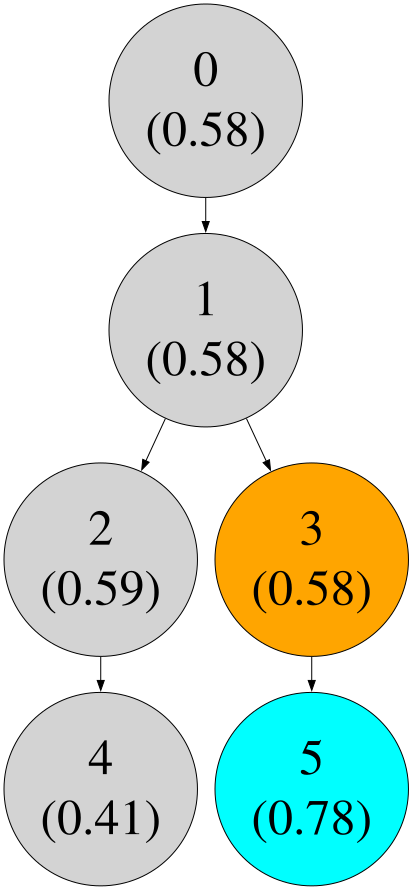

In [17]:
from IPython.display import SVG

SVG('../data/plots/graphviz.svg')